# eDNA Metabarcoding Pipeline Analysis: Lake Geneva (eKOI Database)
### A Reproducible Workflow for MinION Amplicon Sequencing (18S & COI)
**Project:** Genorobotics Semester Project (EPFL)

**Markers:** 18S rRNA (SILVA) & COI (eKOI PR2)

---

## 0. Critical Review: Database Changes

### COI: eKOI PR2 replaces MIDORI2
The COI marker now uses the **eKOI PR2 database** (15,947 sequences) instead of MIDORI2 (2.2M+ sequences).
* **Broader eukaryotic coverage:** eKOI includes protists, fungi, diatoms, and plants — not just metazoans.
* **PR2 taxonomy:** Clean 9-level hierarchy without NCBI taxon ID artifacts.
* **Smaller database:** 66MB vs 9.4GB — dramatically faster SINTAX queries.
* **Trade-off:** Fewer reference sequences means potentially lower species-level resolution for metazoans.

### 18S: SILVA unchanged
The 18S marker continues to use the SILVA v123 database.

### eKOI Taxonomy Mapping
| SINTAX level | PR2 field | Example |
|---|---|---|
| `d:` Domain | Kingdom | Eukaryota |
| `k:` Kingdom | Supergroup | Obazoa, TSAR, Archaeplastida |
| `p:` Phylum | Division | Opisthokonta, Alveolata |
| `c:` Class | Subdivision | Metazoa, Fungi, Apicomplexa |
| `o:` Order | Class | Insecta, Teleostei |
| `f:` Family | Family | resolved from Order/Family |
| `g:` Genus | Genus | Daphnia |
| `s:` Species | Species | Daphnia_galeata |

### Key Question: Does eKOI improve COI ciliate classification?
The previous MIDORI2 analysis showed that ciliates dominated the COI signal but were poorly classified. eKOI's protist coverage should help identify these organisms more accurately.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import re
from pathlib import Path
from Bio import SeqIO
from matplotlib import cm

sns.set_theme(style="whitegrid")
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.size': 12,
    'figure.dpi': 150,
    'savefig.dpi': 300,
    'axes.labelsize': 12,
    'axes.titlesize': 14,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10
})

def clean_sample_names(columns):
    return [c.replace('Sample_barcode', '').replace('Sample_', '') for c in columns]

def get_tax_prefix(df):
    for col in df.columns:
        if col.startswith("SILVA_"):
            return "SILVA"
        if col.startswith("MIDORI2_"):
            return "MIDORI2"
        if col.startswith("MIDORI_"):
            return "MIDORI"
        if col.startswith("eKOI_"):
            return "eKOI"
    return "SILVA"

BASE = Path("out/Water_eDNA_18S_COI_14_01_26")

# Global confidence threshold for taxonomy filtering
CONF_THRESHOLD = 0.8

## Table Headers & Data Structure
Inspect the comprehensive taxonomy CSV files to verify column names and data shape.

In [ ]:
df_18s = pd.read_csv(BASE / 'taxonomy_summary/comprehensive_taxonomy_18S.csv')
df_coi_raw = pd.read_csv(BASE / 'taxonomy_summary/comprehensive_taxonomy_COI.csv')

prefix_18s = get_tax_prefix(df_18s)
prefix_coi = get_tax_prefix(df_coi_raw)

for label, df, pfx in [("18S", df_18s, prefix_18s), ("COI", df_coi_raw, prefix_coi)]:
    print(f"\n{'='*60}")
    print(f"  {label} ({pfx} database)  \u2014  {df.shape[0]} OTUs \u00d7 {df.shape[1]} columns")
    print(f"{'='*60}")
    
    sample_cols = [c for c in df.columns if c.startswith("Sample_")]
    taxonomy_cols = [c for c in df.columns if c.startswith(f"{pfx}_") or c.startswith("NCBI_")]
    meta_cols = [c for c in df.columns if c not in sample_cols + taxonomy_cols]
    
    print(f"\nMetadata columns:  {meta_cols}")
    print(f"Sample columns:    {sample_cols}")
    print(f"Taxonomy columns:  {taxonomy_cols}")
    print(f"\nFirst 3 rows:")
    display(df.head(3))


  18S (SILVA database)  —  59002 OTUs × 36 columns

Metadata columns:  ['OTU_ID', 'Total_Abundance', 'Rank']
Sample columns:    ['Sample_barcode01', 'Sample_barcode02', 'Sample_barcode03', 'Sample_barcode04', 'Sample_barcode05', 'Sample_barcode06', 'Sample_barcode07', 'Sample_barcode08', 'Sample_barcode09', 'Sample_barcode10', 'Sample_barcode11', 'Sample_barcode12', 'Sample_barcode13', 'Sample_barcode14', 'Sample_barcode15', 'Sample_unclassified']
Taxonomy columns:  ['SILVA_Domain', 'SILVA_Domain_Conf', 'SILVA_Phylum', 'SILVA_Phylum_Conf', 'SILVA_Class', 'SILVA_Class_Conf', 'SILVA_Order', 'SILVA_Order_Conf', 'SILVA_Family', 'SILVA_Family_Conf', 'SILVA_Genus', 'SILVA_Genus_Conf', 'SILVA_Species', 'SILVA_Species_Conf', 'NCBI_TopHit', 'NCBI_Identity', 'NCBI_Evalue']

First 3 rows:


,OTU_ID,Total_Abundance,Rank,Sample_barcode01,Sample_barcode02,Sample_barcode03,Sample_barcode04,Sample_barcode05,Sample_barcode06,Sample_barcode07,...,SILVA_Order_Conf,SILVA_Family,SILVA_Family_Conf,SILVA_Genus,SILVA_Genus_Conf,SILVA_Species,SILVA_Species_Conf,NCBI_TopHit,NCBI_Identity,NCBI_Evalue
0,OTU_18S_005421,0.766523,1,0.004390,0.095702,0.082278,0.099657,0.0,0.0,0.006094,...,1.0,Oligotrichia,1.0,Strombidium,1.0,NaN,NaN,NaN,NaN,NaN
1,OTU_18S_000035,0.355367,2,0.020870,0.021060,0.004128,0.006171,0.0,0.0,0.028086,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,OTU_18S_000362,0.310807,3,0.008224,0.016476,0.003853,0.005794,0.0,0.0,0.010984,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN



  COI (eKOI database)  —  6281 OTUs × 36 columns

Metadata columns:  ['OTU_ID', 'Total_Abundance', 'Rank']
Sample columns:    ['Sample_barcode01', 'Sample_barcode02', 'Sample_barcode03', 'Sample_barcode04', 'Sample_barcode05', 'Sample_barcode06', 'Sample_barcode07', 'Sample_barcode08', 'Sample_barcode09', 'Sample_barcode10', 'Sample_barcode11', 'Sample_barcode12', 'Sample_barcode13', 'Sample_barcode14', 'Sample_barcode15', 'Sample_unclassified']
Taxonomy columns:  ['eKOI_Domain', 'eKOI_Domain_Conf', 'eKOI_Phylum', 'eKOI_Phylum_Conf', 'eKOI_Class', 'eKOI_Class_Conf', 'eKOI_Order', 'eKOI_Order_Conf', 'eKOI_Family', 'eKOI_Family_Conf', 'eKOI_Genus', 'eKOI_Genus_Conf', 'eKOI_Species', 'eKOI_Species_Conf', 'NCBI_TopHit', 'NCBI_Identity', 'NCBI_Evalue']

First 3 rows:


,OTU_ID,Total_Abundance,Rank,Sample_barcode01,Sample_barcode02,Sample_barcode03,Sample_barcode04,Sample_barcode05,Sample_barcode06,Sample_barcode07,...,eKOI_Order_Conf,eKOI_Family,eKOI_Family_Conf,eKOI_Genus,eKOI_Genus_Conf,eKOI_Species,eKOI_Species_Conf,NCBI_TopHit,NCBI_Identity,NCBI_Evalue
0,OTU_COI_000076,0.279448,1,0.021097,0.040323,0.042105,0.008237,0.0,0.0,0.01108,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,OTU_COI_005155,0.166667,2,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.00000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,OTU_COI_005391,0.166667,3,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.00000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Confidence Distribution Dashboard
Visualize the SINTAX bootstrap confidence for taxonomy assignments across ranks.
Only assignments with confidence >= 0.8 are stored in the CSV.

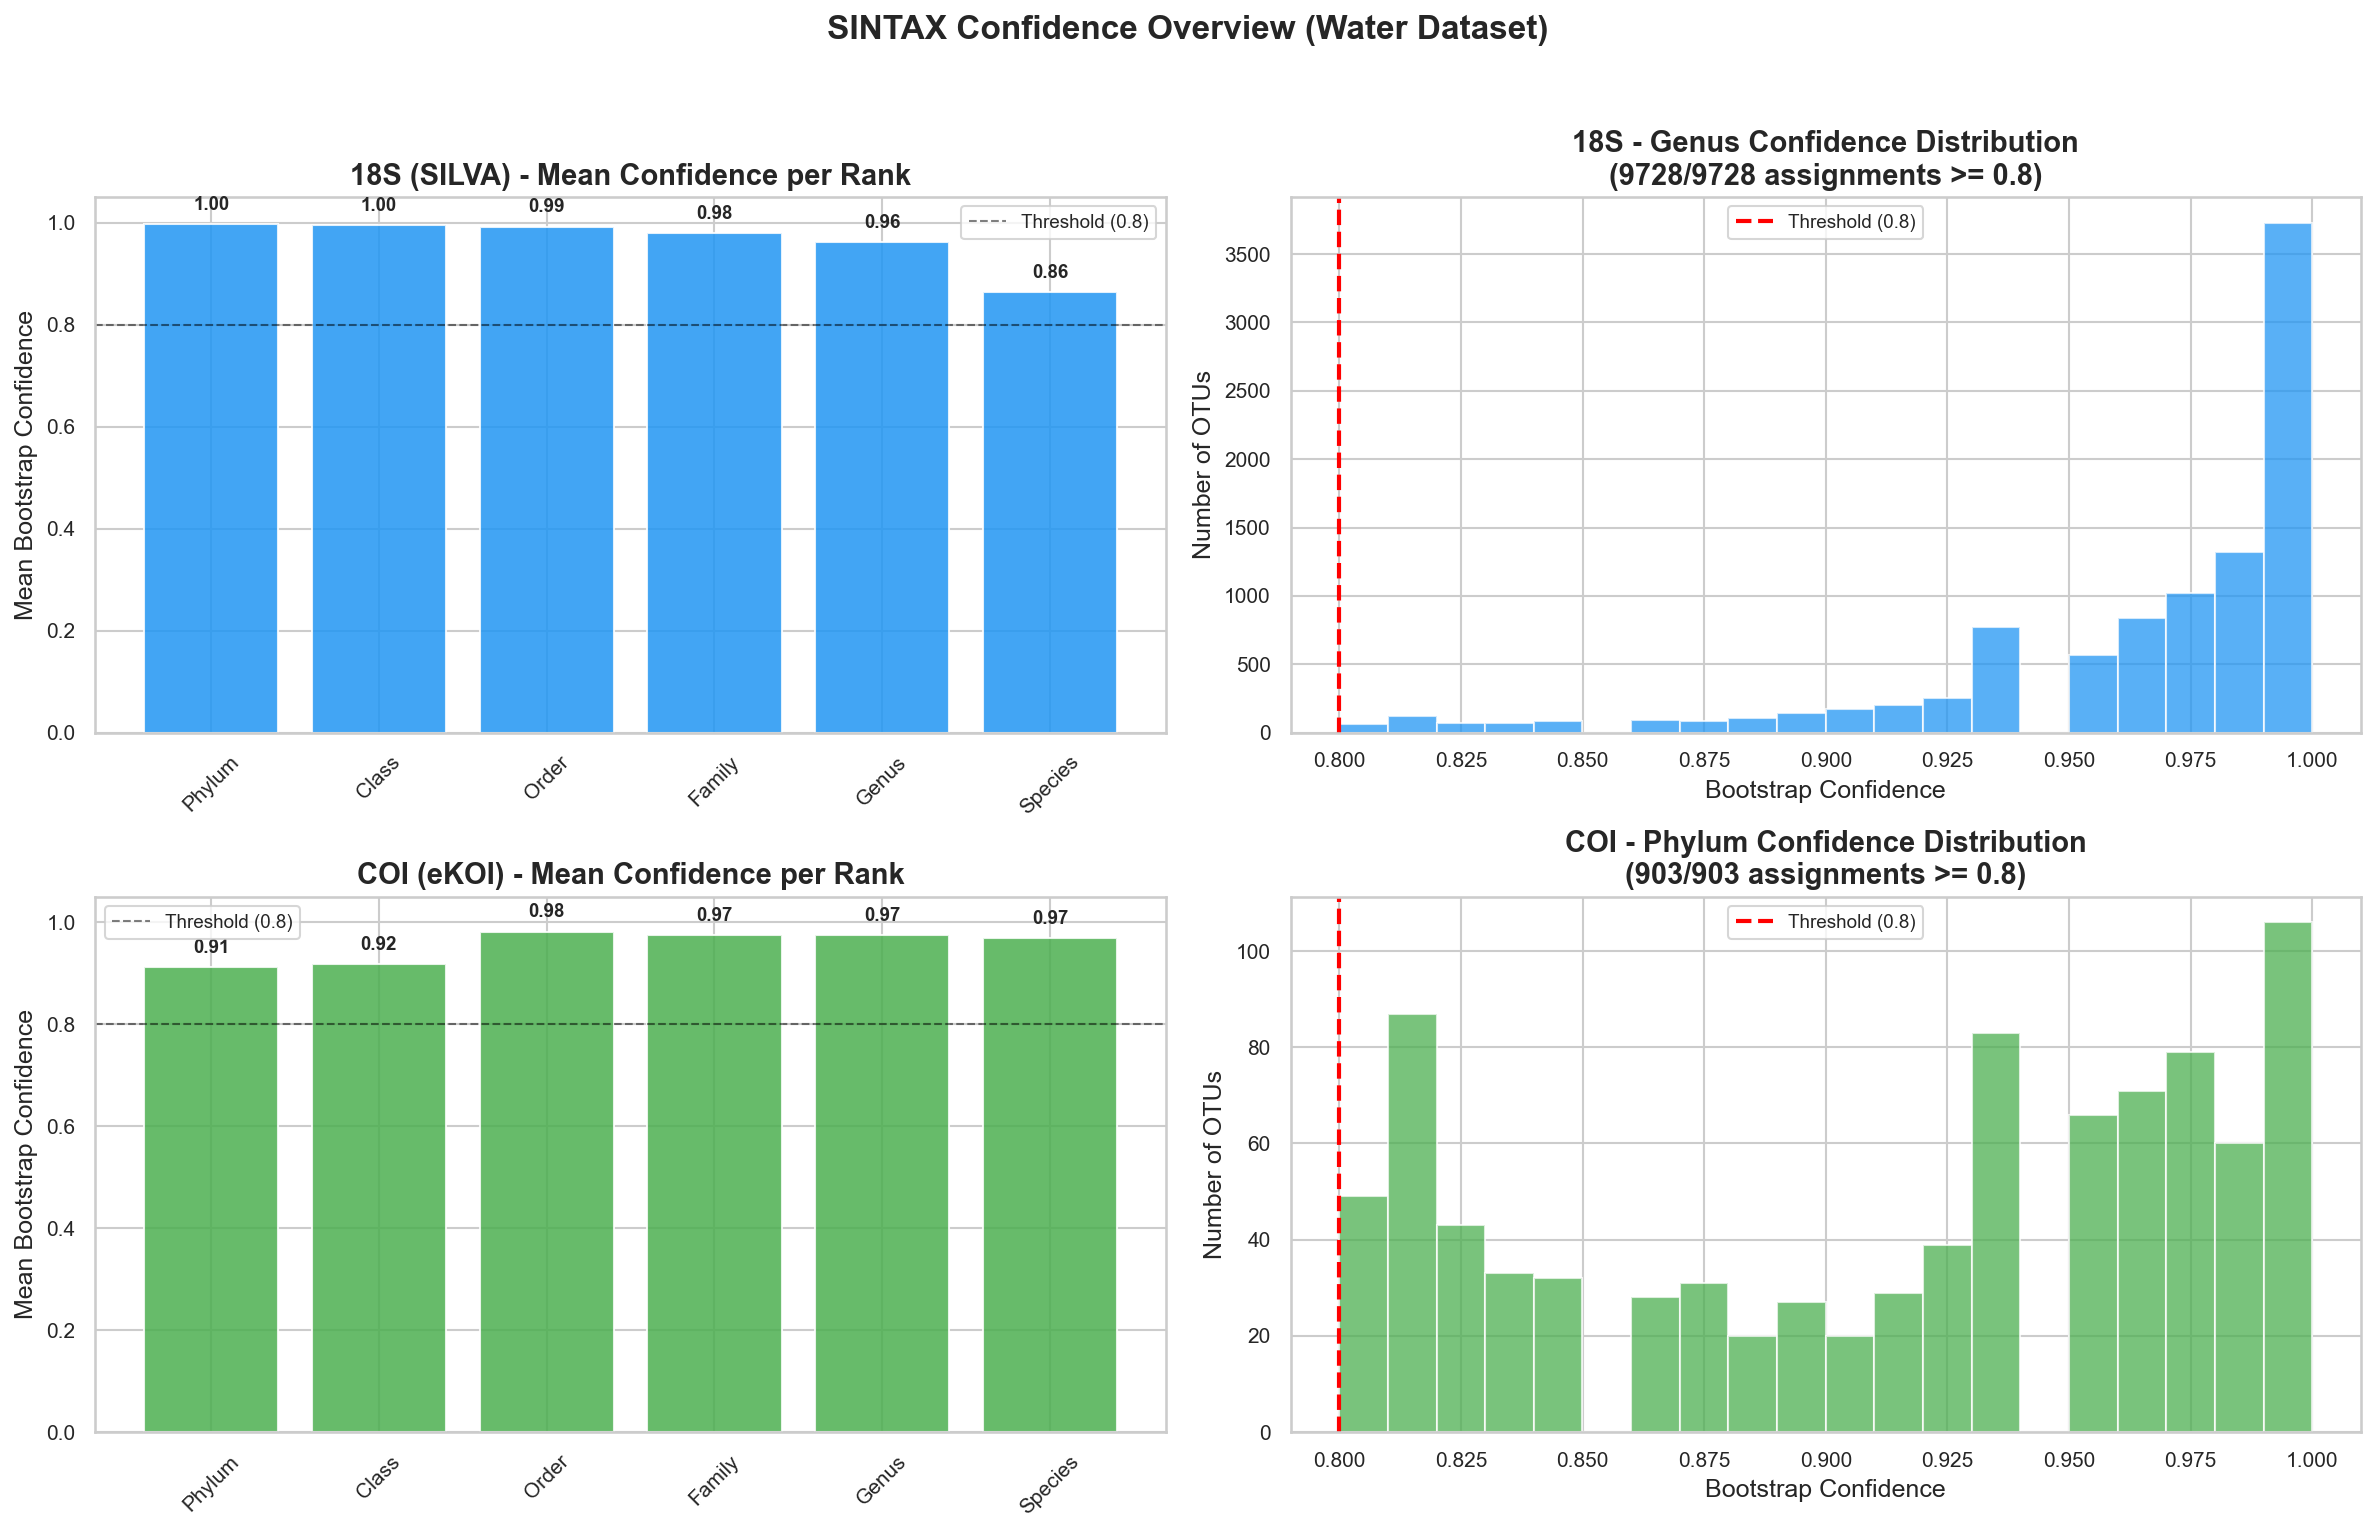

In [ ]:
# Confidence Distribution Dashboard
ranks = ['Phylum', 'Class', 'Order', 'Family', 'Genus', 'Species']

marker_info = [
    ("18S", df_18s, prefix_18s, "#2196F3"),
    ("COI", df_coi_raw, prefix_coi, "#4CAF50"),
]

# Check if confidence columns exist
has_conf = any(c.endswith('_Conf') for c in df_18s.columns) or any(c.endswith('_Conf') for c in df_coi_raw.columns)

if not has_conf:
    print("No confidence columns found in CSV files.")
    print("Regenerate with: bash regenerate_taxonomy.sh")
else:
    fig, axes = plt.subplots(2, 2, figsize=(16, 10))
    
    for row, (marker, df, pfx, color) in enumerate(marker_info):
        # Left: Mean confidence per rank
        ax = axes[row, 0]
        mean_confs = []
        for rank in ranks:
            conf_col = f'{pfx}_{rank}_Conf'
            if conf_col in df.columns:
                vals = pd.to_numeric(df[conf_col], errors='coerce').dropna()
                mean_confs.append(vals.mean() if len(vals) > 0 else 0)
            else:
                mean_confs.append(0)
        
        bar_colors = [color if c >= 0.8 else '#e74c3c' for c in mean_confs]
        bars = ax.bar(ranks, mean_confs, color=bar_colors, alpha=0.85, edgecolor='white')
        ax.axhline(y=0.8, color='black', linestyle='--', linewidth=1, alpha=0.5, label='Threshold (0.8)')
        ax.set_title(f'{marker} ({pfx}) - Mean Confidence per Rank', fontweight='bold')
        ax.set_ylabel('Mean Bootstrap Confidence')
        ax.set_ylim(0, 1.05)
        ax.tick_params(axis='x', rotation=45)
        for bar, val in zip(bars, mean_confs):
            if val > 0:
                ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.02,
                        f'{val:.2f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
        ax.legend(fontsize=9)
        
        # Right: Confidence histogram for best rank
        ax2 = axes[row, 1]
        hist_rank = 'Genus' if pfx == 'SILVA' else 'Phylum'
        conf_col = f'{pfx}_{hist_rank}_Conf'
        if conf_col in df.columns:
            vals = pd.to_numeric(df[conf_col], errors='coerce').dropna()
            if len(vals) > 0:
                ax2.hist(vals, bins=20, color=color, alpha=0.75, edgecolor='white')
                ax2.axvline(x=0.8, color='red', linestyle='--', linewidth=2, label='Threshold (0.8)')
                n_above = (vals >= 0.8).sum()
                ax2.set_title(f'{marker} - {hist_rank} Confidence Distribution\n'
                             f'({n_above}/{len(vals)} assignments >= 0.8)', fontweight='bold')
            else:
                ax2.set_title(f'{marker} - No {hist_rank} assignments', fontweight='bold')
        else:
            ax2.text(0.5, 0.5, f'No {conf_col} column', transform=ax2.transAxes, ha='center')
            ax2.set_title(f'{marker} - {hist_rank} Confidence', fontweight='bold')
        ax2.set_xlabel('Bootstrap Confidence')
        ax2.set_ylabel('Number of OTUs')
        ax2.legend(fontsize=9)
    
    plt.suptitle('SINTAX Confidence Overview (Water Dataset)', fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()


## Database Performance Dashboard

Evaluate how well the reference database classifies our OTUs. Three diagnostic panels per marker:

1. **OTUs classified per rank** — What fraction of OTUs gets any assignment (gray) vs a *confident* assignment (green, ≥ 0.8) at each rank. Shows **coverage breadth + quality**.
2. **Reads covered per rank** — Same but weighted by read abundance. A DB could classify few OTUs that nonetheless represent most reads (or the opposite).
3. **Deepest confident rank** — For each OTU, the deepest rank it reached confidently. Shows the **resolution power** of the DB for this dataset.

Good DB for this marker = high green bars + reads-covered high + most OTUs reaching Genus/Species.

In [ ]:
# Database Performance Dashboard
# Shows how well the reference DB classifies our OTUs: assignment rate per rank,
# confident-assignment rate, read-weighted coverage, and resolution depth.

ranks = ['Phylum', 'Class', 'Order', 'Family', 'Genus', 'Species']
marker_data = [(df_18s, prefix_18s, '18S'), (df_coi_raw, prefix_coi, 'COI')]

def db_stats(df, prefix):
    """Return per-rank stats for a marker."""
    stats = {'rank': [], 'pct_any': [], 'pct_conf': [],
             'pct_reads_any': [], 'pct_reads_conf': []}
    total_otus = len(df)
    total_reads = df['Total_Abundance'].sum() if 'Total_Abundance' in df.columns else df[[c for c in df.columns if c.startswith('Sample_')]].sum().sum()
    for rank in ranks:
        col = f'{prefix}_{rank}'
        conf_col = f'{prefix}_{rank}_Conf'
        if col not in df.columns:
            continue
        has_any = ~df[col].isin(['Unassigned', '', None]) & df[col].notna()
        if conf_col in df.columns:
            conf_vals = pd.to_numeric(df[conf_col], errors='coerce').fillna(0)
            has_conf = has_any & (conf_vals >= CONF_THRESHOLD)
        else:
            has_conf = has_any
        reads_col = 'Total_Abundance' if 'Total_Abundance' in df.columns else None
        if reads_col:
            reads_any = df.loc[has_any, reads_col].sum()
            reads_conf = df.loc[has_conf, reads_col].sum()
        else:
            sample_cols = [c for c in df.columns if c.startswith('Sample_')]
            reads_any = df.loc[has_any, sample_cols].sum().sum()
            reads_conf = df.loc[has_conf, sample_cols].sum().sum()
        stats['rank'].append(rank)
        stats['pct_any'].append(100 * has_any.sum() / total_otus)
        stats['pct_conf'].append(100 * has_conf.sum() / total_otus)
        stats['pct_reads_any'].append(100 * reads_any / total_reads if total_reads > 0 else 0)
        stats['pct_reads_conf'].append(100 * reads_conf / total_reads if total_reads > 0 else 0)
    return stats

def resolution_depth(df, prefix):
    """For each OTU, find deepest confident rank. Returns counts per rank + Unassigned."""
    depths = {'Unassigned': 0}
    for r in ranks:
        depths[r] = 0
    for _, row in df.iterrows():
        deepest = 'Unassigned'
        for rank in ranks:
            col = f'{prefix}_{rank}'
            conf_col = f'{prefix}_{rank}_Conf'
            if col not in df.columns:
                continue
            val = row.get(col, '')
            if pd.isna(val) or val in ('Unassigned', ''):
                continue
            if conf_col in df.columns:
                try:
                    if float(row.get(conf_col, 0) or 0) >= CONF_THRESHOLD:
                        deepest = rank
                except (ValueError, TypeError):
                    pass
            else:
                deepest = rank
        depths[deepest] += 1
    return depths

# Build figure: one row per marker, 3 subplots per row
n_markers = len(marker_data)
fig, axes = plt.subplots(n_markers, 3, figsize=(18, 5 * n_markers))
if n_markers == 1:
    axes = axes.reshape(1, -1)

fig.suptitle('Database Performance Dashboard', fontsize=16, fontweight='bold', y=1.00)

for row_idx, (df, prefix, label) in enumerate(marker_data):
    s = db_stats(df, prefix)
    x = np.arange(len(s['rank']))
    width = 0.4

    # --- Panel 1: OTU-based assignment rate ---
    ax = axes[row_idx, 0]
    ax.bar(x - width/2, s['pct_any'], width, color='#95a5a6', label='Any assignment')
    ax.bar(x + width/2, s['pct_conf'], width, color='#2d8a4e', label=f'Confident (\u2265 {CONF_THRESHOLD})')
    ax.set_xticks(x)
    ax.set_xticklabels(s['rank'], rotation=45)
    ax.set_ylabel('% of OTUs')
    ax.set_ylim(0, 105)
    ax.set_title(f'{label}: OTUs classified per rank', fontweight='bold', fontsize=11)
    ax.legend(fontsize=8)
    for xi, (a, c) in enumerate(zip(s['pct_any'], s['pct_conf'])):
        ax.text(xi - width/2, a + 1, f'{a:.0f}%', ha='center', fontsize=7)
        ax.text(xi + width/2, c + 1, f'{c:.0f}%', ha='center', fontsize=7, color='#2d8a4e')

    # --- Panel 2: Read-weighted assignment rate ---
    ax = axes[row_idx, 1]
    ax.bar(x - width/2, s['pct_reads_any'], width, color='#95a5a6', label='Any assignment')
    ax.bar(x + width/2, s['pct_reads_conf'], width, color='#2d8a4e', label=f'Confident (\u2265 {CONF_THRESHOLD})')
    ax.set_xticks(x)
    ax.set_xticklabels(s['rank'], rotation=45)
    ax.set_ylabel('% of reads')
    ax.set_ylim(0, 105)
    ax.set_title(f'{label}: Reads covered per rank', fontweight='bold', fontsize=11)
    ax.legend(fontsize=8)

    # --- Panel 3: Resolution depth ---
    ax = axes[row_idx, 2]
    depths = resolution_depth(df, prefix)
    labels_d = ['Unassigned'] + ranks
    counts_d = [depths.get(l, 0) for l in labels_d]
    total_d = sum(counts_d)
    pcts_d = [100 * c / total_d if total_d > 0 else 0 for c in counts_d]
    colors_d = ['#c0392b'] + ['#e6a817', '#f39c12', '#27ae60', '#16a085', '#2d8a4e', '#1a5f37']
    bars = ax.bar(labels_d, pcts_d, color=colors_d)
    ax.set_ylabel('% of OTUs')
    ax.set_ylim(0, max(pcts_d) * 1.15 if pcts_d else 100)
    ax.set_title(f'{label}: Deepest confident rank', fontweight='bold', fontsize=11)
    ax.tick_params(axis='x', rotation=45)
    for xi, (p, c) in enumerate(zip(pcts_d, counts_d)):
        ax.text(xi, p + 0.5, f'{p:.0f}%\n(n={c})', ha='center', fontsize=7)

plt.tight_layout()
plt.show()

# Print summary table
print("\n" + "=" * 70)
print("DATABASE PERFORMANCE SUMMARY")
print("=" * 70)
for df, prefix, label in marker_data:
    s = db_stats(df, prefix)
    print(f"\n{label}  (DB: {prefix})")
    print(f"  {'Rank':<10} {'% OTUs any':>12} {'% OTUs conf':>14} {'% reads conf':>14}")
    for i, r in enumerate(s['rank']):
        print(f"  {r:<10} {s['pct_any'][i]:>11.1f}% {s['pct_conf'][i]:>13.1f}% {s['pct_reads_conf'][i]:>13.1f}%")


## Raw Read Length Distributions (Pre-Clustering)

✓ 18S: 226,443 reads, median=1857bp, range=1500-2799bp
✓ COI: 14,495 reads, median=834bp, range=500-900bp


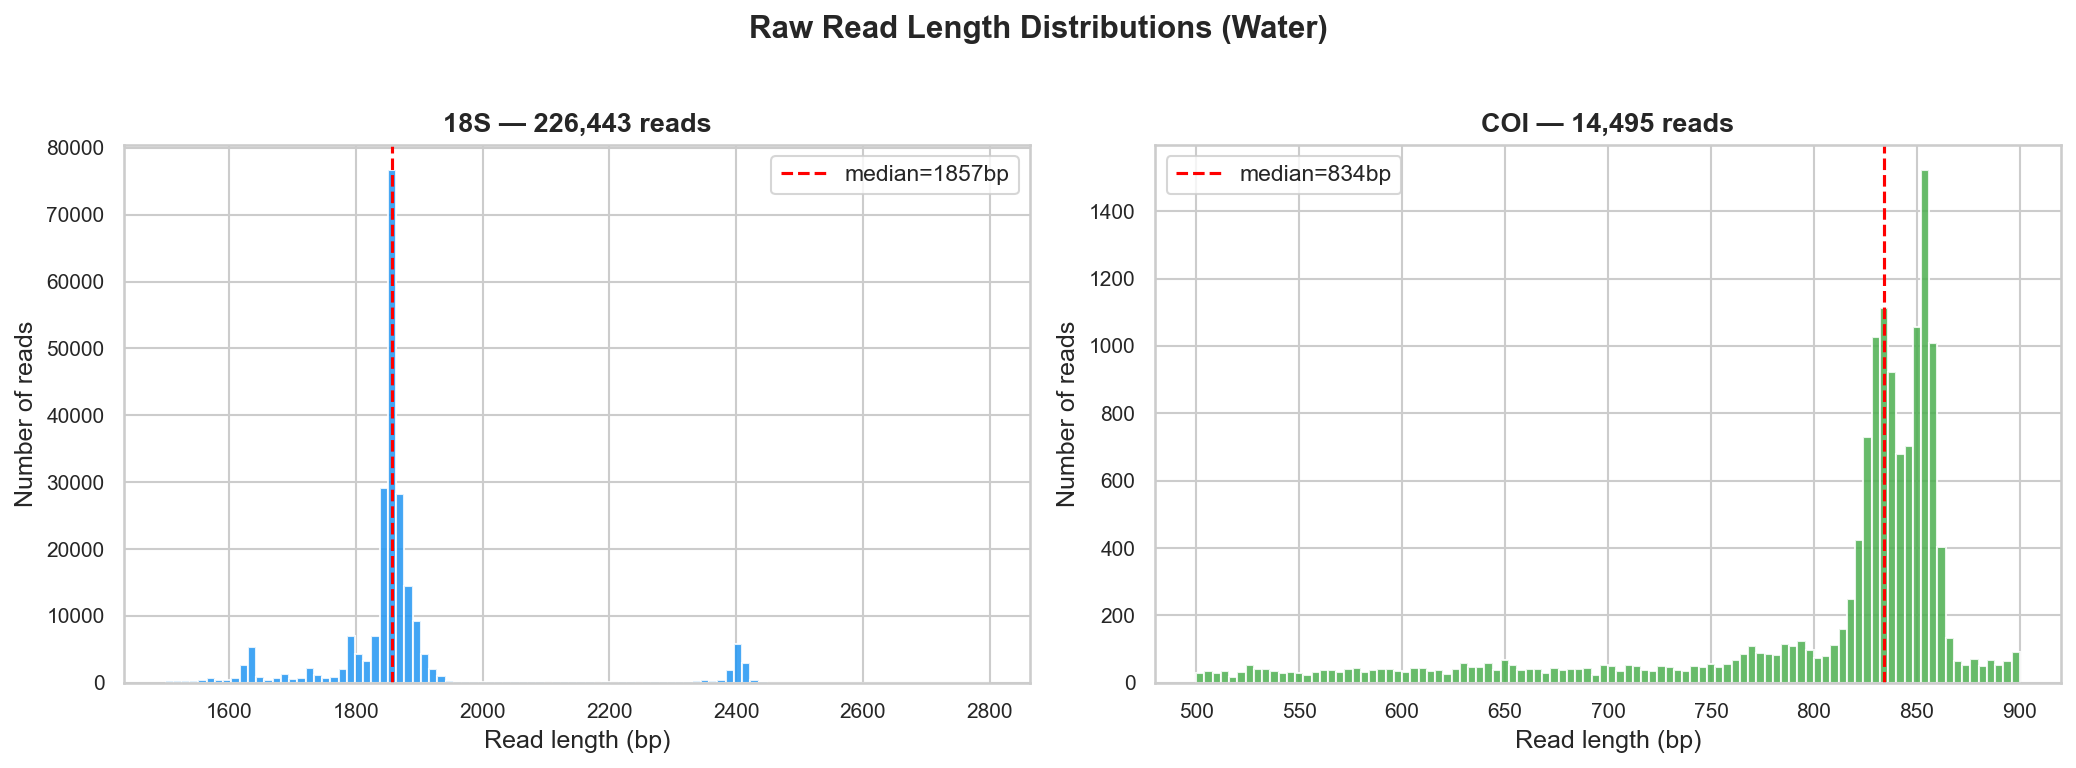

In [ ]:
import gzip

barcode_dirs = sorted(BASE.glob("barcode*"))
marker_lengths = {"18S": [], "COI": []}
marker_colors_raw = {"18S": "#2196F3", "COI": "#4CAF50"}

for bd in barcode_dirs:
    for marker in marker_lengths:
        fq = bd / f"filtered_reads_{marker}.fastq.gz"
        if fq.exists():
            with gzip.open(str(fq), 'rt') as f:
                for i, line in enumerate(f):
                    if i % 4 == 1:
                        marker_lengths[marker].append(len(line.strip()))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for i, (marker, lengths) in enumerate(marker_lengths.items()):
    ax = axes[i]
    if lengths:
        ax.hist(lengths, bins=100, color=marker_colors_raw[marker], edgecolor="white", alpha=0.85)
        ax.axvline(np.median(lengths), color="red", ls="--", lw=1.5,
                   label=f"median={np.median(lengths):.0f}bp")
        ax.set_title(f"{marker} \u2014 {len(lengths):,} reads", fontsize=13, fontweight="bold")
        ax.set_xlabel("Read length (bp)")
        ax.set_ylabel("Number of reads")
        ax.legend()
        print(f"\u2713 {marker}: {len(lengths):,} reads, median={np.median(lengths):.0f}bp, "
              f"range={min(lengths)}-{max(lengths)}bp")
    else:
        ax.text(0.5, 0.5, f"{marker}\nNo reads found", ha='center', va='center', transform=ax.transAxes)

plt.suptitle("Raw Read Length Distributions (Water)", fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

## Consensus OTU Sequence Length Distributions

✓ 18S: 35237 OTUs, median=1853bp, range=1500-2809bp
✓ COI: 4162 OTUs, median=829bp, range=417-902bp


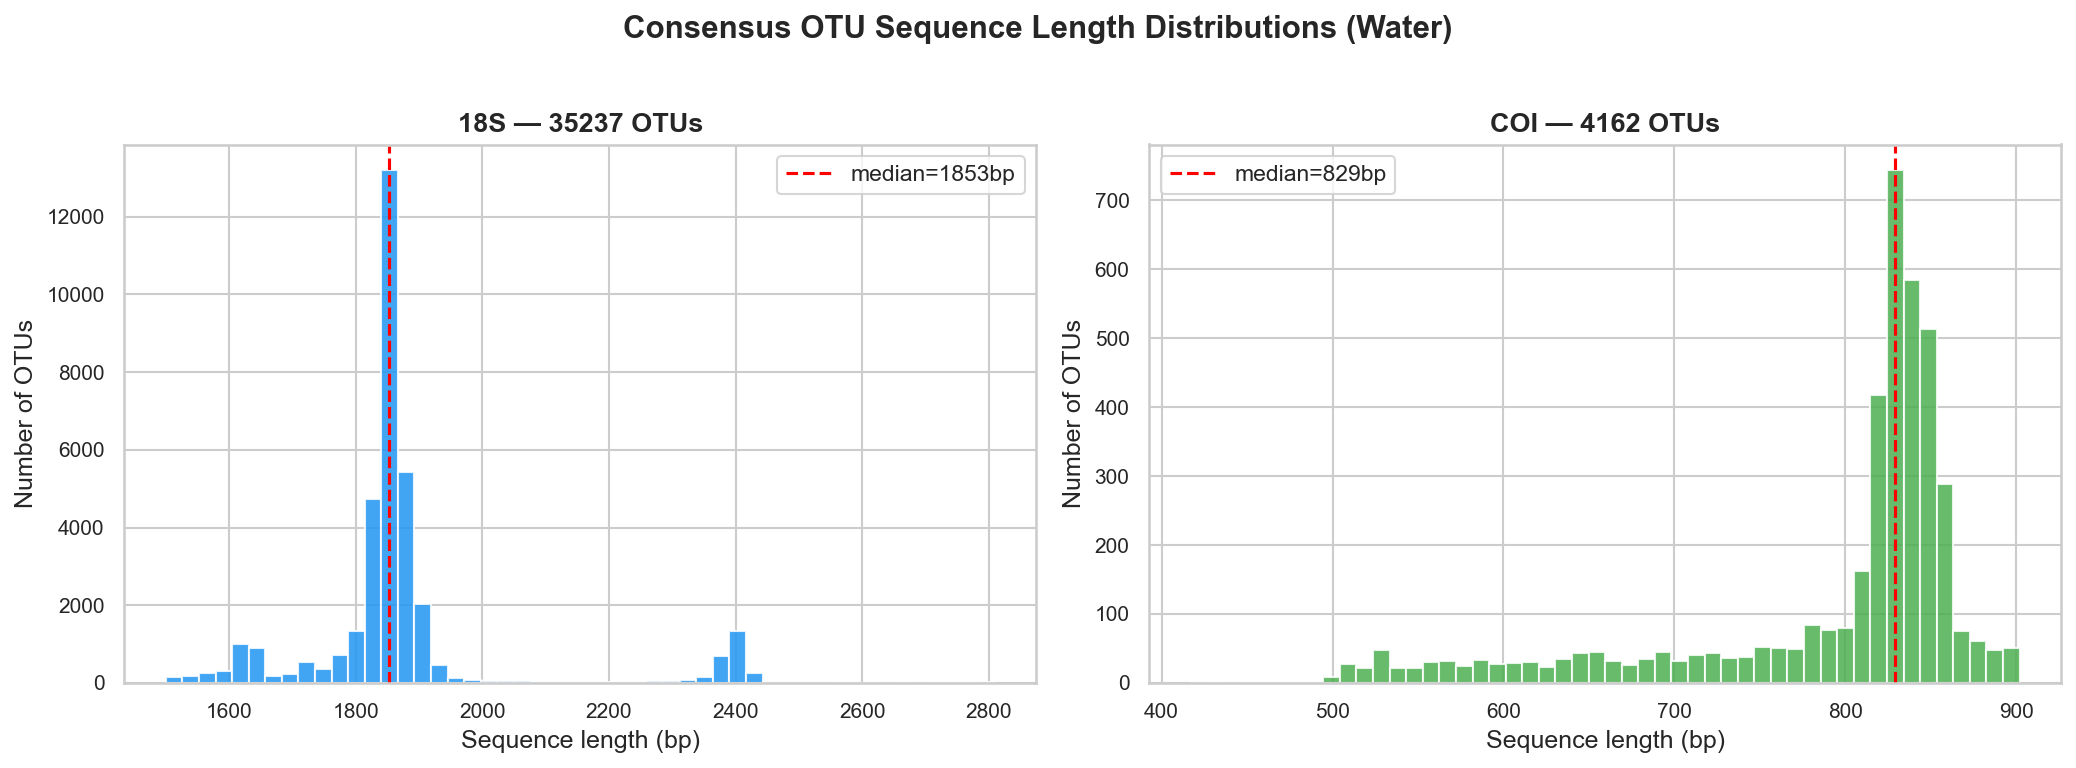

In [ ]:
fasta_files = {
    "18S": BASE / "temp_clustering/consensus_18S_clean.fasta",
    "COI": BASE / "temp_clustering/consensus_COI_clean.fasta",
}
marker_colors = {"18S": "#2196F3", "COI": "#4CAF50"}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for i, (marker, path) in enumerate(fasta_files.items()):
    ax = axes[i]
    if path.exists():
        lengths = [len(rec.seq) for rec in SeqIO.parse(str(path), "fasta")]
        ax.hist(lengths, bins=50, color=marker_colors[marker], edgecolor="white", alpha=0.85)
        ax.axvline(np.median(lengths), color="red", ls="--", lw=1.5,
                   label=f"median={np.median(lengths):.0f}bp")
        ax.set_title(f"{marker} \u2014 {len(lengths)} OTUs", fontsize=13, fontweight="bold")
        ax.set_xlabel("Sequence length (bp)")
        ax.set_ylabel("Number of OTUs")
        ax.legend()
        print(f"\u2713 {marker}: {len(lengths)} OTUs, median={np.median(lengths):.0f}bp, "
              f"range={min(lengths)}-{max(lengths)}bp")
    else:
        ax.text(0.5, 0.5, f"{marker}\nFASTA not found", ha='center', va='center', transform=ax.transAxes)

plt.suptitle("Consensus OTU Sequence Length Distributions (Water)", fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

---
# Part A: 18S Marker Biodiversity Analysis (SILVA)
*Objective: Characterize the planktonic community using the 18S marker. This section is unchanged from the MIDORI2 analysis since 18S still uses SILVA.*

## A.1a Broad Taxonomic Structure (18S)

In [ ]:
sample_cols_18s = [c for c in df_18s.columns if c.startswith('Sample_') and 'unclassified' not in c]
phylum_col_18s = f'{prefix_18s}_Phylum'

# Confidence filter: blank low-confidence phylum assignments
_phylum_conf = f'{prefix_18s}_Phylum_Conf'
if _phylum_conf in df_18s.columns:
    df_18s.loc[pd.to_numeric(df_18s[_phylum_conf], errors='coerce').fillna(0) < CONF_THRESHOLD, phylum_col_18s] = ''
df_18s[phylum_col_18s] = df_18s[phylum_col_18s].fillna('Unassigned')
phylum_18s = df_18s.groupby(phylum_col_18s)[sample_cols_18s].sum()

phylum_18s['Total'] = phylum_18s.sum(axis=1)
phylum_18s = phylum_18s.sort_values('Total', ascending=False)
top_phyla = phylum_18s.head(10).index

plot_data = phylum_18s.loc[top_phyla].drop(columns='Total')
others = phylum_18s.loc[~phylum_18s.index.isin(top_phyla)].drop(columns='Total').sum()
plot_data.loc['Others'] = others

fig, ax = plt.subplots(figsize=(12, 6))
plot_data.columns = clean_sample_names(plot_data.columns)
plot_data.T.plot(kind='bar', stacked=True, ax=ax, width=0.85, cmap='tab20')

ax.set_title(f'Lake Community Composition \u2014 Phylum (18S, {prefix_18s})', fontweight='bold')
ax.set_xlabel('Sample ID')
ax.set_ylabel('Relative Abundance')
ax.legend(title='Phylum', bbox_to_anchor=(1.02, 1), loc='upper left')

plt.tight_layout()
plt.show()

## A.1b Class-Level Breakdown (18S)

In [ ]:
class_col_18s = f'{prefix_18s}_Class'
# Confidence filter: blank low-confidence class assignments
_class_conf = f'{prefix_18s}_Class_Conf'
if _class_conf in df_18s.columns:
    df_18s.loc[pd.to_numeric(df_18s[_class_conf], errors='coerce').fillna(0) < CONF_THRESHOLD, class_col_18s] = ''
df_18s[class_col_18s] = df_18s[class_col_18s].fillna('Unassigned')
class_18s = df_18s.groupby(class_col_18s)[sample_cols_18s].sum()
class_18s = class_18s.drop('Unassigned', errors='ignore')

class_18s['Total'] = class_18s.sum(axis=1)
class_18s = class_18s.sort_values('Total', ascending=False)
top_classes = class_18s.head(15).index

plot_cls = class_18s.loc[top_classes].drop(columns='Total')
others_cls = class_18s.loc[~class_18s.index.isin(top_classes)].drop(columns='Total').sum()
plot_cls.loc['Others'] = others_cls

num_colors = len(plot_cls)
colors = cm.tab20(np.linspace(0, 1, num_colors))
custom_colors = []
for i, cls_name in enumerate(plot_cls.index):
    if cls_name == 'Unassigned':
        custom_colors.append('#D3D3D3')
    elif cls_name == 'Others':
        custom_colors.append('#696969')
    else:
        custom_colors.append(colors[i])

fig, ax = plt.subplots(figsize=(12, 7))
plot_cls.columns = clean_sample_names(plot_cls.columns)
plot_cls = plot_cls.div(plot_cls.sum(axis=0), axis=1) * 100  # normalize to %
plot_cls = plot_cls.fillna(0)
plot_cls.T.plot(kind='bar', stacked=True, ax=ax, width=0.85, color=custom_colors)

ax.set_title(f'Class-Level Composition (18S, {prefix_18s})', fontweight='bold')
ax.set_ylabel('Relative Abundance (%)')
handles, labels = ax.get_legend_handles_labels()
ax.legend(reversed(handles), reversed(labels), bbox_to_anchor=(1.02, 1), loc='upper left', title='Class')

# Mark samples with no assigned taxa
for _idx, _sample in enumerate(plot_cls.columns):
    if plot_cls[_sample].sum() == 0:
        ax.text(_idx, 2, 'ND', ha='center', va='bottom',
                fontsize=9, color='gray', fontstyle='italic')
ax.set_ylim(0, 105)
plt.tight_layout()
plt.show()

## A.2 Order-Level Breakdown (18S)

In [ ]:
order_col_18s = f'{prefix_18s}_Order'
# Confidence filter: blank low-confidence order assignments
_order_conf = f'{prefix_18s}_Order_Conf'
if _order_conf in df_18s.columns:
    df_18s.loc[pd.to_numeric(df_18s[_order_conf], errors='coerce').fillna(0) < CONF_THRESHOLD, order_col_18s] = ''
df_18s[order_col_18s] = df_18s[order_col_18s].fillna('Unassigned')
order_18s = df_18s.groupby(order_col_18s)[sample_cols_18s].sum()
order_18s = order_18s.drop('Unassigned', errors='ignore')

order_18s['Total'] = order_18s.sum(axis=1)
order_18s = order_18s.sort_values('Total', ascending=False)
top_orders_18s = order_18s.head(15).index

plot_ord_18s = order_18s.loc[top_orders_18s].drop(columns='Total')
others_ord_18s = order_18s.loc[~order_18s.index.isin(top_orders_18s)].drop(columns='Total').sum()
plot_ord_18s.loc['Others'] = others_ord_18s

fig, ax = plt.subplots(figsize=(12, 7))
plot_ord_18s.columns = clean_sample_names(plot_ord_18s.columns)
plot_ord_18s = plot_ord_18s.div(plot_ord_18s.sum(axis=0), axis=1) * 100  # normalize to %
plot_ord_18s = plot_ord_18s.fillna(0)
plot_ord_18s.T.plot(kind='bar', stacked=True, ax=ax, width=0.85, cmap='tab20')

ax.set_title(f'Order-Level Composition (18S, {prefix_18s})', fontweight='bold')
ax.set_ylabel('Relative Abundance (%)')
ax.legend(title='Order', bbox_to_anchor=(1.02, 1), loc='upper left')

for _idx, _sample in enumerate(plot_ord_18s.columns):
    if plot_ord_18s[_sample].sum() == 0:
        ax.text(_idx, 2, 'ND', ha='center', va='bottom',
                fontsize=9, color='gray', fontstyle='italic')
ax.set_ylim(0, 105)
plt.tight_layout()
plt.show()

## A.3 Genus-Level Top 20 (18S)
Top genera detected by the 18S marker with confidence annotations.

In [ ]:
# Top 20 Genera — Confident assignments only (confidence >= 0.8)
genus_col = f'{prefix_18s}_Genus'
conf_col = f'{prefix_18s}_Genus_Conf'
df_18s[genus_col] = df_18s[genus_col].fillna('Unassigned')

# Filter to only OTUs with genus confidence >= 0.8
if conf_col in df_18s.columns:
    mask_conf = pd.to_numeric(df_18s[conf_col], errors='coerce') >= 0.8
    df_conf = df_18s[mask_conf].copy()
else:
    df_conf = df_18s[df_18s[genus_col] != 'Unassigned'].copy()

genus_agg = df_conf.groupby(genus_col)[sample_cols_18s].sum()
genus_agg = genus_agg.drop('Unassigned', errors='ignore')
genus_agg['Total'] = genus_agg.sum(axis=1)
genus_agg = genus_agg.sort_values('Total', ascending=False)
top20 = genus_agg.head(20)

# Mean confidence per genus
genus_conf = {}
if conf_col in df_conf.columns:
    for genus in top20.index:
        mask = df_conf[genus_col] == genus
        vals = pd.to_numeric(df_conf.loc[mask, conf_col], errors='coerce').dropna()
        genus_conf[genus] = vals.mean() if len(vals) > 0 else None

fig, ax = plt.subplots(figsize=(10, 8))
sns.barplot(x=top20['Total'], y=top20.index, palette='viridis', ax=ax)
ax.set_title(f'Top 20 Genera — Confident Only (\u2265 0.8) (18S, {prefix_18s})', fontweight='bold')
ax.set_xlabel('Total Abundance')
ax.set_ylabel('Genus')

if genus_conf:
    for j, genus in enumerate(top20.index):
        conf = genus_conf.get(genus)
        if conf is not None:
            ax.text(top20.loc[genus, 'Total'] + 0.001, j,
                    f' ({conf:.2f})', va='center', fontsize=9, color='darkred', fontweight='bold')

plt.tight_layout()
plt.show()

### Top 20 Genera by Abundance — All Confidences (18S)
Same marker but showing ALL genus assignments regardless of confidence, ranked by abundance. Bars are color-coded by mean confidence level.

In [ ]:
# Top 20 Genera by ABUNDANCE — All confidence levels
genus_col = f'{prefix_18s}_Genus'
conf_col = f'{prefix_18s}_Genus_Conf'
df_tmp = df_18s.copy()
df_tmp[genus_col] = df_tmp[genus_col].fillna('Unassigned')

genus_abund = df_tmp.groupby(genus_col)[sample_cols_18s].sum()
genus_abund = genus_abund.drop('Unassigned', errors='ignore')
genus_abund['Total'] = genus_abund.sum(axis=1)
genus_abund = genus_abund.sort_values('Total', ascending=False)
top20 = genus_abund.head(20)

# Mean confidence per genus
raw_conf = {}
if conf_col in df_tmp.columns:
    for genus in top20.index:
        mask = df_tmp[genus_col] == genus
        vals = pd.to_numeric(df_tmp.loc[mask, conf_col], errors='coerce').dropna()
        raw_conf[genus] = vals.mean() if len(vals) > 0 else None

fig, ax = plt.subplots(figsize=(11, 8))
colors = []
for genus in top20.index:
    c = raw_conf.get(genus)
    if c is None:
        colors.append('#999999')
    elif c >= 0.8:
        colors.append('#2d8a4e')
    elif c >= 0.5:
        colors.append('#e6a817')
    else:
        colors.append('#c0392b')

bars = ax.barh(range(len(top20)), top20['Total'].values[::-1], color=colors[::-1], height=0.7)
ax.set_yticks(range(len(top20)))
ax.set_yticklabels(top20.index[::-1], fontsize=9)
ax.set_xlabel('Total Abundance', fontsize=11)
ax.set_title(f'Top 20 Genera by Abundance — All Confidences (18S, {prefix_18s})',
             fontweight='bold', fontsize=12)

xmax = top20['Total'].max()
for j, genus in enumerate(top20.index[::-1]):
    c = raw_conf.get(genus)
    if c is not None:
        color = '#2d8a4e' if c >= 0.8 else '#e6a817' if c >= 0.5 else '#c0392b'
        ax.text(top20.loc[genus, 'Total'] + xmax * 0.01, j,
                f' {c:.2f}', va='center', fontsize=9, fontweight='bold', color=color)

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#2d8a4e', label='\u2265 0.80 (confident)'),
    Patch(facecolor='#e6a817', label='0.50 \u2013 0.79 (moderate)'),
    Patch(facecolor='#c0392b', label='< 0.50 (low confidence)'),
]
ax.legend(handles=legend_elements, loc='lower right', fontsize=8,
          title='Mean confidence', title_fontsize=9, framealpha=0.9)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

## A.2 Taxonomic Resolution Decay (18S)

In [ ]:
ranks = ['Phylum', 'Class', 'Order', 'Family', 'Genus', 'Species']
levels_18s = [f'{prefix_18s}_{r}' for r in ranks]
unassigned_counts_18s = []

for level in levels_18s:
    conf_level = level + '_Conf'
    no_taxonomy = df_18s[level].isin(['Unassigned', '', np.nan])
    low_conf = pd.to_numeric(df_18s[conf_level], errors='coerce').fillna(0) < CONF_THRESHOLD if conf_level in df_18s.columns else pd.Series(False, index=df_18s.index)
    n_unassigned = (no_taxonomy | low_conf).sum()
    pct = (n_unassigned / len(df_18s)) * 100
    unassigned_counts_18s.append(pct)

plt.figure(figsize=(8, 5))
sns.barplot(x=ranks, y=unassigned_counts_18s, color="salmon")
plt.title(f'Taxonomic Resolution Decay (18S, {prefix_18s})', fontweight='bold')
plt.ylabel('% of OTUs Unassigned')
plt.xticks(rotation=45)
plt.ylim(0, 100)
plt.tight_layout()
plt.show()

---
# Part B: COI Marker Biodiversity Analysis (eKOI)
*Objective: Characterize the metazoan/eukaryotic community using COI with the eKOI PR2 database.*

### Key changes from MIDORI2:
* eKOI taxonomy is cleaner — no NCBI taxon ID artifacts, no rank prefix stripping needed.
* "Phylum" = PR2 Division (Opisthokonta, Stramenopiles, Alveolata)
* "Class" = PR2 Subdivision (Metazoa, Fungi, Apicomplexa)
* Better protist/ciliate coverage should reveal what MIDORI2 missed.

## B.1a Broad Taxonomic Structure (COI, eKOI)

In [ ]:
df_coi = df_coi_raw.copy()
sample_cols_coi = [c for c in df_coi.columns if c.startswith('Sample_') and 'unclassified' not in c]
phylum_col_coi = f'{prefix_coi}_Phylum'

# Confidence filter: blank low-confidence phylum assignments
_phylum_conf = f'{prefix_coi}_Phylum_Conf'
if _phylum_conf in df_coi.columns:
    df_coi.loc[pd.to_numeric(df_coi[_phylum_conf], errors='coerce').fillna(0) < CONF_THRESHOLD, phylum_col_coi] = ''
df_coi[phylum_col_coi] = df_coi[phylum_col_coi].fillna('Unassigned')
phylum_coi = df_coi.groupby(phylum_col_coi)[sample_cols_coi].sum()

phylum_coi['Total'] = phylum_coi.sum(axis=1)
phylum_coi = phylum_coi.sort_values('Total', ascending=False)
top_phyla_coi = phylum_coi.head(10).index

plot_data_coi = phylum_coi.loc[top_phyla_coi].drop(columns='Total')
others_coi = phylum_coi.loc[~phylum_coi.index.isin(top_phyla_coi)].drop(columns='Total').sum()
plot_data_coi.loc['Others'] = others_coi

fig, ax = plt.subplots(figsize=(12, 6))
plot_data_coi.columns = clean_sample_names(plot_data_coi.columns)
plot_data_coi.T.plot(kind='bar', stacked=True, ax=ax, width=0.85, cmap='tab20')

ax.set_title(f'Lake Community Composition \u2014 Phylum (COI, {prefix_coi})', fontweight='bold')
ax.set_xlabel('Sample ID')
ax.set_ylabel('Relative Abundance')
ax.legend(title='Phylum', bbox_to_anchor=(1.02, 1), loc='upper left')

plt.tight_layout()
plt.show()

## B.1b Class-Level Breakdown (COI, eKOI)
In eKOI, "Class" = PR2 Subdivision. Look for **Metazoa**, **Fungi**, **Apicomplexa**, etc.

In [ ]:
class_col_coi = f'{prefix_coi}_Class'
# Confidence filter: blank low-confidence class assignments
_class_conf = f'{prefix_coi}_Class_Conf'
if _class_conf in df_coi.columns:
    df_coi.loc[pd.to_numeric(df_coi[_class_conf], errors='coerce').fillna(0) < CONF_THRESHOLD, class_col_coi] = ''
df_coi[class_col_coi] = df_coi[class_col_coi].fillna('Unassigned')
class_coi = df_coi.groupby(class_col_coi)[sample_cols_coi].sum()
class_coi = class_coi.drop('Unassigned', errors='ignore')

class_coi['Total'] = class_coi.sum(axis=1)
class_coi = class_coi.sort_values('Total', ascending=False)
top_classes_coi = class_coi.head(15).index

plot_cls_coi = class_coi.loc[top_classes_coi].drop(columns='Total')
others_cls_coi = class_coi.loc[~class_coi.index.isin(top_classes_coi)].drop(columns='Total').sum()
plot_cls_coi.loc['Others'] = others_cls_coi

num_colors_coi = len(plot_cls_coi)
colors_coi = cm.tab20(np.linspace(0, 1, num_colors_coi))
custom_colors_coi = []
for i, cls_name in enumerate(plot_cls_coi.index):
    if cls_name == 'Unassigned':
        custom_colors_coi.append('#D3D3D3')
    elif cls_name == 'Others':
        custom_colors_coi.append('#696969')
    else:
        custom_colors_coi.append(colors_coi[i])

fig, ax = plt.subplots(figsize=(12, 7))
plot_cls_coi.columns = clean_sample_names(plot_cls_coi.columns)
plot_cls_coi = plot_cls_coi.div(plot_cls_coi.sum(axis=0), axis=1) * 100  # normalize to %
plot_cls_coi = plot_cls_coi.fillna(0)
plot_cls_coi.T.plot(kind='bar', stacked=True, ax=ax, width=0.85, color=custom_colors_coi)

ax.set_title(f'Class-Level Composition (COI, {prefix_coi})', fontweight='bold')
ax.set_ylabel('Relative Abundance (%)')
handles, labels = ax.get_legend_handles_labels()
ax.legend(reversed(handles), reversed(labels), bbox_to_anchor=(1.02, 1), loc='upper left', title='Class')

# Mark samples with no assigned taxa
for _idx, _sample in enumerate(plot_cls_coi.columns):
    if plot_cls_coi[_sample].sum() == 0:
        ax.text(_idx, 2, 'ND', ha='center', va='bottom',
                fontsize=9, color='gray', fontstyle='italic')
ax.set_ylim(0, 105)
plt.tight_layout()
plt.show()

## B.2 Order-Level Breakdown (COI, eKOI)
In eKOI, "Order" = PR2 Class level (e.g., Insecta, Teleostei, Mammalia for Metazoa).

In [ ]:
order_col_coi = f'{prefix_coi}_Order'
# Confidence filter: blank low-confidence order assignments
_order_conf = f'{prefix_coi}_Order_Conf'
if _order_conf in df_coi.columns:
    df_coi.loc[pd.to_numeric(df_coi[_order_conf], errors='coerce').fillna(0) < CONF_THRESHOLD, order_col_coi] = ''
df_coi[order_col_coi] = df_coi[order_col_coi].fillna('Unassigned')
order_coi = df_coi.groupby(order_col_coi)[sample_cols_coi].sum()
order_coi = order_coi.drop('Unassigned', errors='ignore')

order_coi['Total'] = order_coi.sum(axis=1)
order_coi = order_coi.sort_values('Total', ascending=False)
top_orders_coi = order_coi.head(15).index

plot_ord_coi = order_coi.loc[top_orders_coi].drop(columns='Total')
others_ord_coi = order_coi.loc[~order_coi.index.isin(top_orders_coi)].drop(columns='Total').sum()
plot_ord_coi.loc['Others'] = others_ord_coi

fig, ax = plt.subplots(figsize=(12, 7))
plot_ord_coi.columns = clean_sample_names(plot_ord_coi.columns)
plot_ord_coi = plot_ord_coi.div(plot_ord_coi.sum(axis=0), axis=1) * 100  # normalize to %
plot_ord_coi = plot_ord_coi.fillna(0)
plot_ord_coi.T.plot(kind='bar', stacked=True, ax=ax, width=0.85, cmap='tab20')

ax.set_title(f'Order-Level Composition (COI, {prefix_coi})', fontweight='bold')
ax.set_ylabel('Relative Abundance (%)')
ax.legend(title='Order', bbox_to_anchor=(1.02, 1), loc='upper left')

# Mark samples with no assigned taxa
for _idx, _sample in enumerate(plot_ord_coi.columns):
    if plot_ord_coi[_sample].sum() == 0:
        ax.text(_idx, 2, 'ND', ha='center', va='bottom',
                fontsize=9, color='gray', fontstyle='italic')
ax.set_ylim(0, 105)
plt.tight_layout()
plt.show()

## B.3 Genus-Level Top 20 (COI, eKOI)

In [ ]:
# Top 20 Genera — Confident assignments only (confidence >= 0.8)
genus_col = f'{prefix_coi}_Genus'
conf_col = f'{prefix_coi}_Genus_Conf'
df_coi[genus_col] = df_coi[genus_col].fillna('Unassigned')

# Filter to only OTUs with genus confidence >= 0.8
if conf_col in df_coi.columns:
    mask_conf = pd.to_numeric(df_coi[conf_col], errors='coerce') >= 0.8
    df_conf = df_coi[mask_conf].copy()
else:
    df_conf = df_coi[df_coi[genus_col] != 'Unassigned'].copy()

genus_agg = df_conf.groupby(genus_col)[sample_cols_coi].sum()
genus_agg = genus_agg.drop('Unassigned', errors='ignore')
genus_agg['Total'] = genus_agg.sum(axis=1)
genus_agg = genus_agg.sort_values('Total', ascending=False)
top20 = genus_agg.head(20)

# Mean confidence per genus
genus_conf = {}
if conf_col in df_conf.columns:
    for genus in top20.index:
        mask = df_conf[genus_col] == genus
        vals = pd.to_numeric(df_conf.loc[mask, conf_col], errors='coerce').dropna()
        genus_conf[genus] = vals.mean() if len(vals) > 0 else None

fig, ax = plt.subplots(figsize=(10, 8))
sns.barplot(x=top20['Total'], y=top20.index, palette='viridis', ax=ax)
ax.set_title(f'Top 20 Genera — Confident Only (\u2265 0.8) (COI, {prefix_coi})', fontweight='bold')
ax.set_xlabel('Total Abundance')
ax.set_ylabel('Genus')

if genus_conf:
    for j, genus in enumerate(top20.index):
        conf = genus_conf.get(genus)
        if conf is not None:
            ax.text(top20.loc[genus, 'Total'] + 0.001, j,
                    f' ({conf:.2f})', va='center', fontsize=9, color='darkred', fontweight='bold')

plt.tight_layout()
plt.show()

### Top 20 Genera by Abundance — All Confidences (COI)
Same marker but showing ALL genus assignments regardless of confidence, ranked by abundance. Bars are color-coded by mean confidence level.

In [ ]:
# Top 20 Genera by ABUNDANCE — All confidence levels
genus_col = f'{prefix_coi}_Genus'
conf_col = f'{prefix_coi}_Genus_Conf'
df_tmp = df_coi.copy()
df_tmp[genus_col] = df_tmp[genus_col].fillna('Unassigned')

genus_abund = df_tmp.groupby(genus_col)[sample_cols_coi].sum()
genus_abund = genus_abund.drop('Unassigned', errors='ignore')
genus_abund['Total'] = genus_abund.sum(axis=1)
genus_abund = genus_abund.sort_values('Total', ascending=False)
top20 = genus_abund.head(20)

# Mean confidence per genus
raw_conf = {}
if conf_col in df_tmp.columns:
    for genus in top20.index:
        mask = df_tmp[genus_col] == genus
        vals = pd.to_numeric(df_tmp.loc[mask, conf_col], errors='coerce').dropna()
        raw_conf[genus] = vals.mean() if len(vals) > 0 else None

fig, ax = plt.subplots(figsize=(11, 8))
colors = []
for genus in top20.index:
    c = raw_conf.get(genus)
    if c is None:
        colors.append('#999999')
    elif c >= 0.8:
        colors.append('#2d8a4e')
    elif c >= 0.5:
        colors.append('#e6a817')
    else:
        colors.append('#c0392b')

bars = ax.barh(range(len(top20)), top20['Total'].values[::-1], color=colors[::-1], height=0.7)
ax.set_yticks(range(len(top20)))
ax.set_yticklabels(top20.index[::-1], fontsize=9)
ax.set_xlabel('Total Abundance', fontsize=11)
ax.set_title(f'Top 20 Genera by Abundance — All Confidences (COI, {prefix_coi})',
             fontweight='bold', fontsize=12)

xmax = top20['Total'].max()
for j, genus in enumerate(top20.index[::-1]):
    c = raw_conf.get(genus)
    if c is not None:
        color = '#2d8a4e' if c >= 0.8 else '#e6a817' if c >= 0.5 else '#c0392b'
        ax.text(top20.loc[genus, 'Total'] + xmax * 0.01, j,
                f' {c:.2f}', va='center', fontsize=9, fontweight='bold', color=color)

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#2d8a4e', label='\u2265 0.80 (confident)'),
    Patch(facecolor='#e6a817', label='0.50 \u2013 0.79 (moderate)'),
    Patch(facecolor='#c0392b', label='< 0.50 (low confidence)'),
]
ax.legend(handles=legend_elements, loc='lower right', fontsize=8,
          title='Mean confidence', title_fontsize=9, framealpha=0.9)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

## B.4 Taxonomic Resolution Comparison: 18S (SILVA) vs COI (eKOI)

In [ ]:
ranks = ['Phylum', 'Class', 'Order', 'Family', 'Genus', 'Species']

levels_18s = [f'{prefix_18s}_{r}' for r in ranks]
unassigned_18s = []
for level in levels_18s:
    conf_level = level + '_Conf'
    no_taxonomy = df_18s[level].isin(['Unassigned', '', np.nan])
    low_conf = pd.to_numeric(df_18s[conf_level], errors='coerce').fillna(0) < CONF_THRESHOLD if conf_level in df_18s.columns else pd.Series(False, index=df_18s.index)
    n_unassigned = (no_taxonomy | low_conf).sum()
    pct = (n_unassigned / len(df_18s)) * 100
    unassigned_18s.append(pct)

levels_coi = [f'{prefix_coi}_{r}' for r in ranks]
unassigned_coi = []
for level in levels_coi:
    conf_level = level + '_Conf'
    no_taxonomy = df_coi[level].isin(['Unassigned', '', np.nan])
    low_conf = pd.to_numeric(df_coi[conf_level], errors='coerce').fillna(0) < CONF_THRESHOLD if conf_level in df_coi.columns else pd.Series(False, index=df_coi.index)
    n_unassigned = (no_taxonomy | low_conf).sum()
    pct = (n_unassigned / len(df_coi)) * 100
    unassigned_coi.append(pct)

fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(ranks))
width = 0.35

bars1 = ax.bar(x - width/2, unassigned_18s, width, label=f'18S ({prefix_18s})', color='salmon', alpha=0.8)
bars2 = ax.bar(x + width/2, unassigned_coi, width, label=f'COI ({prefix_coi})', color='steelblue', alpha=0.8)

ax.set_title('Taxonomic Resolution Decay: 18S (SILVA) vs COI (eKOI)', fontweight='bold')
ax.set_ylabel('% of OTUs Unassigned')
ax.set_xticks(x)
ax.set_xticklabels(ranks, rotation=45)
ax.set_ylim(0, 100)
ax.legend()

plt.tight_layout()
plt.show()

## Forensics: BLAST Identification (18S)
BLAST validation of the top 18S OTUs provides ground-truth identification beyond what SINTAX can offer.
Compare these species-level results with the SILVA taxonomy assignments above.

In [ ]:
def parse_blast_file(filepath):
    """Parses the custom text output from script 6_blast_top_otus.py"""
    data = []
    try:
        with open(filepath, 'r') as f:
            lines = f.readlines()
        start_reading = False
        for line in lines:
            if line.startswith('---'):
                start_reading = True
                continue
            if not start_reading or not line.strip(): continue
            parts = line.split('|')
            if len(parts) >= 4:
                otu_id = parts[0].strip()
                species = parts[2].strip()
                identity_str = parts[3].strip().replace('%', '')
                try:
                    reads = float(parts[1].strip())
                    identity = float(identity_str) if identity_str and identity_str != '-' else None
                    data.append({'OTU': otu_id, 'Species': species, 'Abundance': reads, 'Identity': identity})
                except: continue
    except FileNotFoundError:
        print("BLAST file not found.")
        return pd.DataFrame()
    return pd.DataFrame(data)

df_blast = parse_blast_file('out/Water_eDNA_18S_COI_14_01_26/blast_results/blast_top10_18S.txt')
if not df_blast.empty:
    df_blast = df_blast.sort_values('Abundance', ascending=True)

    # Build clean labels: Species (short OTU suffix)
    labels = []
    for _, row in df_blast.iterrows():
        otu_short = row['OTU'].split('_')[-1]  # e.g. "005421"
        labels.append(f"{row['Species']}  [{otu_short}]")
    df_blast['Label'] = labels

    # Color by identity tier
    colors = []
    for _, row in df_blast.iterrows():
        if row['Identity'] is None:
            colors.append('#999999')
        elif row['Identity'] >= 97:
            colors.append('#2d8a4e')   # species-level green
        elif row['Identity'] >= 90:
            colors.append('#e6a817')   # genus-level amber
        else:
            colors.append('#c0392b')   # uncertain red

    fig, ax = plt.subplots(figsize=(11, max(3, len(df_blast) * 0.55)))
    bars = ax.barh(range(len(df_blast)), df_blast['Abundance'].values,
                   color=colors, edgecolor='white', height=0.7)

    ax.set_yticks(range(len(df_blast)))
    ax.set_yticklabels(df_blast['Label'].values, fontsize=9)
    ax.set_xlabel('Relative Abundance', fontsize=11)
    ax.set_title('Top 18S OTUs — Closest Species Match (BLAST vs NCBI)', fontweight='bold', fontsize=13, pad=12)

    # Annotate identity at bar end
    xmax = df_blast['Abundance'].max()
    for j, (_, row) in enumerate(df_blast.iterrows()):
        if row['Identity'] is not None:
            ax.text(row['Abundance'] + xmax * 0.015, j,
                    f"{row['Identity']:.1f}%", va='center',
                    fontsize=9, fontweight='bold', color=colors[j])
        else:
            ax.text(row['Abundance'] + xmax * 0.015, j,
                    "N/A", va='center', fontsize=9, color='#999999')

    # Add legend for identity tiers
    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor='#2d8a4e', label='\u2265 97% (species)'),
        Patch(facecolor='#e6a817', label='90-97% (genus)'),
        Patch(facecolor='#c0392b', label='< 90% (uncertain)'),
    ]
    ax.legend(handles=legend_elements, loc='lower right', fontsize=8,
              title='Identity level', title_fontsize=9, framealpha=0.9)

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.set_xlim(0, xmax * 1.18)

    plt.tight_layout()
    plt.show()
else:
    print("No valid BLAST data found to plot.")

## Forensics: BLAST Identification (COI, eKOI)
BLAST validation of the top COI OTUs — compare with the eKOI SINTAX taxonomy above.

In [ ]:
df_blast = parse_blast_file('out/Water_eDNA_18S_COI_14_01_26/blast_results/blast_top10_COI.txt')
if not df_blast.empty:
    df_blast = df_blast.sort_values('Abundance', ascending=True)

    # Build clean labels: Species (short OTU suffix)
    labels = []
    for _, row in df_blast.iterrows():
        otu_short = row['OTU'].split('_')[-1]  # e.g. "005421"
        labels.append(f"{row['Species']}  [{otu_short}]")
    df_blast['Label'] = labels

    # Color by identity tier
    colors = []
    for _, row in df_blast.iterrows():
        if row['Identity'] is None:
            colors.append('#999999')
        elif row['Identity'] >= 97:
            colors.append('#2d8a4e')   # species-level green
        elif row['Identity'] >= 90:
            colors.append('#e6a817')   # genus-level amber
        else:
            colors.append('#c0392b')   # uncertain red

    fig, ax = plt.subplots(figsize=(11, max(3, len(df_blast) * 0.55)))
    bars = ax.barh(range(len(df_blast)), df_blast['Abundance'].values,
                   color=colors, edgecolor='white', height=0.7)

    ax.set_yticks(range(len(df_blast)))
    ax.set_yticklabels(df_blast['Label'].values, fontsize=9)
    ax.set_xlabel('Relative Abundance', fontsize=11)
    ax.set_title('Top COI OTUs — Closest Species Match (BLAST vs NCBI)', fontweight='bold', fontsize=13, pad=12)

    # Annotate identity at bar end
    xmax = df_blast['Abundance'].max()
    for j, (_, row) in enumerate(df_blast.iterrows()):
        if row['Identity'] is not None:
            ax.text(row['Abundance'] + xmax * 0.015, j,
                    f"{row['Identity']:.1f}%", va='center',
                    fontsize=9, fontweight='bold', color=colors[j])
        else:
            ax.text(row['Abundance'] + xmax * 0.015, j,
                    "N/A", va='center', fontsize=9, color='#999999')

    # Add legend for identity tiers
    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor='#2d8a4e', label='\u2265 97% (species)'),
        Patch(facecolor='#e6a817', label='90-97% (genus)'),
        Patch(facecolor='#c0392b', label='< 90% (uncertain)'),
    ]
    ax.legend(handles=legend_elements, loc='lower right', fontsize=8,
              title='Identity level', title_fontsize=9, framealpha=0.9)

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.set_xlim(0, xmax * 1.18)

    plt.tight_layout()
    plt.show()
else:
    print("No valid BLAST data found to plot.")

---
## Part D: Cross-Marker Comparison (18S SILVA vs COI eKOI)
Compare the taxonomic profiles from both markers to identify concordance and unique detections.

In [ ]:
# Compare genus-level detections between 18S and COI
genus_col_18s = f'{prefix_18s}_Genus'
genus_col_coi = f'{prefix_coi}_Genus'

# Only include genera with confidence >= threshold
_g_conf_18s = f'{prefix_18s}_Genus_Conf'
if _g_conf_18s in df_18s.columns:
    _mask_18s = pd.to_numeric(df_18s[_g_conf_18s], errors='coerce').fillna(0) >= CONF_THRESHOLD
    _df_18s_g = df_18s[_mask_18s]
else:
    _df_18s_g = df_18s
genera_18s = set(_df_18s_g[genus_col_18s].dropna().unique()) - {'Unassigned', ''}
_g_conf_coi = f'{prefix_coi}_Genus_Conf'
if _g_conf_coi in df_coi.columns:
    _mask_coi = pd.to_numeric(df_coi[_g_conf_coi], errors='coerce').fillna(0) >= CONF_THRESHOLD
    _df_coi_g = df_coi[_mask_coi]
else:
    _df_coi_g = df_coi
genera_coi = set(_df_coi_g[genus_col_coi].dropna().unique()) - {'Unassigned', ''}  

shared = genera_18s & genera_coi
only_18s = genera_18s - genera_coi
only_coi = genera_coi - genera_18s

print(f"Genera detected by 18S (SILVA): {len(genera_18s)}")
print(f"Genera detected by COI (eKOI):  {len(genera_coi)}")
print(f"Shared genera:                  {len(shared)}")
print(f"Only in 18S:                    {len(only_18s)}")
print(f"Only in COI:                    {len(only_coi)}")

if shared:
    print(f"\nShared genera (first 20): {sorted(shared)[:20]}")